In [121]:
import numpy as np
import jax
import jax.numpy as jnp
import util.functions as functions
from models.FNO import CAPE_FNO
import pybamm
import flax

In [122]:
from skopt.utils import use_named_args
from skopt.space import Real
from skopt import gp_minimize

In [123]:
from util.FNO_util import preprocess_data, train_test_split, remove_padding, normalise_diffusion
# from util.plotting import create_plot_FNO_results, create_plot_voltage
from util.postprocess import filter_anode_cathode

In [124]:
family = "CC"
N_total = 33000
data = np.load(f"../data/{family}_{N_total}.npz")
split_seed = 42
test_ratio = 0.1

In [125]:
parameter_name = "Prada2013"
params_bat = pybamm.ParameterValues(parameter_name)

C = params_bat["Nominal cell capacity [A.h]"]
Dan = params_bat["Negative particle diffusivity [m2.s-1]"]
Dca = params_bat["Positive particle diffusivity [m2.s-1]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
epsan = params_bat["Negative electrode active material volume fraction"]
epsca = params_bat["Positive electrode active material volume fraction"]
cs_max_a = params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c = params_bat["Maximum concentration in positive electrode [mol.m-3]"]
Lan = params_bat["Negative electrode thickness [m]"]
Lca = params_bat["Positive electrode thickness [m]"]
A = params_bat["Electrode height [m]"] * params_bat["Electrode width [m]"]

EPS = 1e-12
t_max = 3600

In [126]:
train_data, test_data = train_test_split(data, N_total=N_total, test_ratio=test_ratio, seed=split_seed)  # noqa: F405

In [127]:
func_I = np.array(test_data["current"])

### Anode data ###
cn_anode = np.array(test_data["cn_anode"])
c0_anode = np.array(test_data["c0_anode"])
D_anode = np.array(test_data["Dan"])

### Cathode data ###
cn_cathode = np.array(test_data["cn_cathode"])
c0_cathode = np.array(test_data["c0_cathode"])
D_cathode = np.array(test_data["Dca"])

In [128]:
D_anode = normalise_diffusion(D_anode)
D_cathode = normalise_diffusion(D_cathode)

In [129]:
parameter_name = "Prada2013"
params_bat = pybamm.ParameterValues(parameter_name)
cs_max_a = params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c = params_bat["Maximum concentration in positive electrode [mol.m-3]"]
cs_min_a = 0.0
cs_min_c = 0.0

In [130]:
cn_anode, cn_cathode, mask = filter_anode_cathode(cn_anode, cn_cathode,
                                                    anode_lo=cs_min_a, anode_hi=cs_max_a, 
                                                    cathode_lo=cs_min_c, cathode_hi=cs_max_c)

In [131]:
func_I.shape

(3300, 75)

In [132]:
func_I = func_I[mask]
c0_anode = c0_anode[mask]
c0_cathode = c0_cathode[mask]
D_anode = D_anode[mask]
D_cathode = D_cathode[mask]

In [133]:
# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

In [134]:
X_anode, Y_anode = preprocess_data(func_I, c0_anode, cn_anode, num_samples_I, num_samples_c0, padding_r, padding_t)
X_cathode, Y_cathode = preprocess_data(func_I, c0_cathode, cn_cathode, num_samples_I, num_samples_c0, padding_r, padding_t)

In [135]:
# Assume these hyperparameters
k_modes = 10
fno_depth = 8
hidden_channels = 64
input_channels = 4 # We should automate this TODO
output_channels = 1
cape_hidden_size = 32

In [136]:
test_seed = 0
N_test = func_I.shape[0]
rng = np.random.default_rng(test_seed)
test_idx = rng.integers(0, N_test)

In [137]:
model = CAPE_FNO(k_modes=k_modes, input_channels= input_channels, 
                 fno_depth=fno_depth, cape_hidden_size = cape_hidden_size, 
                 hidden_channels=hidden_channels, output_channels=output_channels)

main_key = jax.random.PRNGKey(split_seed)
# Initialize parameters
dummy_D = jax.random.normal(main_key, (1,1))
params = model.init(main_key, X_anode[:1,...], dummy_D)

# Forward pass
out = model.apply(params, X_anode[:1,...], dummy_D)

In [138]:
anode_file = "../trained_models/cape_fno/anode_CC_2025-05-29_11-07-33.msgpack"
cathode_file = "../trained_models/cape_fno/cathode_CC_2025-05-29_11-31-53.msgpack"

params_anode = functions.load_model_params(anode_file)
params_cathode = functions.load_model_params(cathode_file)

params_anode = flax.serialization.from_bytes(params, params_anode)
params_cathode = flax.serialization.from_bytes(params, params_cathode)

In [139]:
LOG10_D_MIN, LOG10_D_MAX = -15.0, -12.0

In [140]:
#OCP Anode LFP
def U_OCP_an(sto):
    u_eq = (
        1.9793 * jnp.exp(-39.3631 * sto)
        + 0.2482
        - 0.0909 * jnp.tanh(29.8538 * (sto - 0.1234))
        - 0.04478 * jnp.tanh(14.9159 * (sto - 0.2769))
        - 0.0205 * jnp.tanh(30.4444 * (sto - 0.6103))
    )

    return u_eq

#OCP Cathode LFP
def U_OCP_ca(sto):

    c1 = -150 * sto
    c2 = -30 * (1 - sto)
    k = 3.4077 - 0.020269 * sto + 0.5 * jnp.exp(c1) - 0.9 * jnp.exp(c2)

    return k


In [141]:
R_gas = params_bat['Ideal gas constant [J.K-1.mol-1]']
F = params_bat['Faraday constant [C.mol-1]']
Temp = params_bat["Ambient temperature [K]"]

In [142]:
V_pred_list = []
c_an_surf_list = []
c_ca_surf_list = []

In [143]:
@jax.jit
def inference_step(func_I_truth, X_anode_truth, X_cathode_truth, D_anode_candidate, D_cathode_candidate):
    cn_anode = model.apply(params_anode,X_anode_truth, D_anode_candidate)
    cn_cathode = model.apply(params_cathode,X_cathode_truth, D_cathode_candidate)

    cn_anode_reshape = remove_padding(cn_anode, padding_r = padding_r, padding_t = padding_t)
    cn_cathode_reshape = remove_padding(cn_cathode, padding_r = padding_r, padding_t = padding_t)

    cn_anode_surf = cn_anode_reshape[:, -1, :].squeeze()
    cn_cathode_surf = cn_cathode_reshape[:, -1, :].squeeze()

    cn_anode_surf   = jnp.clip(cn_anode_surf,   EPS, 1.0 - EPS)
    cn_cathode_surf = jnp.clip(cn_cathode_surf, EPS, 1.0 - EPS)

    #print(cn_anode_surf.shape, cn_cathode_surf.shape)

    j_anode   = jnp.sqrt(cn_anode_surf * (1.0 - cn_anode_surf))
    j_cathode = jnp.sqrt(cn_cathode_surf * (1.0 - cn_cathode_surf))

    xan = functions.in_arcsinh(-func_I_truth, Ran, epsan, Lan, A)
    xca = functions.in_arcsinh(-func_I_truth, Rca, epsca, Lca, A)

    V_pred = U_OCP_ca(cn_cathode_surf) - U_OCP_an(cn_anode_surf) - 2 * R_gas*Temp/F * jnp.arcsinh(0.5*xan/(j_anode)) - 2 * R_gas*Temp/F * jnp.arcsinh(0.5*xca/(j_cathode))
    return V_pred

In [144]:
# ---- design space ----------------------------------------
dimensions = [
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dan"),
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dca"),
]

In [145]:
V_data = functions.post_proc_true(params_bat, func_I[test_idx], cn_anode[test_idx,-1,:], cn_cathode[test_idx,-1,:], Ran, Rca, epsan, epsca, Lan, Lca, A)
assert np.isfinite(V_data).all()

In [146]:
@use_named_args(dimensions)
def obj_voltage(log10_Dan, log10_Dca):
    # --- 1.  normalise the candidate diffusivities ------------
    log10_Dan_norm = normalise_diffusion(jnp.array(log10_Dan).reshape(-1,1))
    log10_Dca_norm = normalise_diffusion(jnp.array(log10_Dca).reshape(-1,1))
    # --- 2.  CAPE-FNO predictions of c(r,t) ---------------
    V_pred = inference_step(func_I[test_idx],
        X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
        log10_Dan_norm, log10_Dca_norm
    )
    V_pred_list.append(V_pred)

    # --- 4.  voltage RMSE (you can use MAE or any other scalar) -------------
    rmse = jnp.sqrt(jnp.mean((V_pred - V_data) ** 2))
    return float(rmse)

In [147]:
res = gp_minimize(
    obj_voltage,
    dimensions=dimensions,
    n_calls=60,            # ±25–35 evaluations per dimension is usually plenty
    n_initial_points=12,   # random Sobol/Bach search first
    acq_func="EI",         # expected improvement
    random_state=0,
)

best_log10_Dan, best_log10_Dca = res.x
print(f"Best log10(Dan) = {best_log10_Dan:.3f}")
print(f"Best log10(Dca) = {best_log10_Dca:.3f}")
print(f"Voltage-curve RMSE = {res.fun:.4e}")

ValueError: Input y contains infinity or a value too large for dtype('float64').

In [ ]:
V_best = inference_step(func_I[test_idx],
    X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
    jnp.array(best_log10_Dan).reshape(-1,1), jnp.array(best_log10_Dca).reshape(-1,1)
)
print(f"Best voltage prediction: {V_best}")

Best voltage prediction: [1.6605238  1.6697668  1.6720961  1.6698507  1.6625412  1.6505327
 1.6299865  1.594371   1.3785039  0.44548696 0.41277388 0.396896
 0.38703915 0.38098708 0.37734613 0.37524942 0.37429243 0.37387237
 0.37256804 0.37076384 0.36869553 0.3654223  0.36125404 0.35631046
 0.35065687 0.34429517 0.33823803 0.3319981  0.32584155 0.31972373
 0.31384683 0.3080829  0.30281556 0.29824162 0.29434034 0.29116672
 0.28874373 0.28709626 0.28620443 0.28609106 0.28682545 0.28830022
 0.29009172 0.29209962 0.29416597 0.2962612  0.2980912  0.29932326
 0.29972348 0.29964256 0.29859644 0.29713348 0.2949359  0.29255906
 0.29014465 0.2874106  0.28523272 0.28340748 0.2819604  0.2811258
 0.28119785 0.2821002  0.2840833  0.28740415 0.29207876 0.29829466
 0.30637518 0.31628826 0.32977754 0.34932786 0.3792643  0.443425
 1.5961554  1.6442349  1.6665359 ]


In [ ]:
log_Dan_true = float(D_anode[test_idx])
log_Dca_true = float(D_cathode[test_idx])

In [ ]:
log_Dan_true = (log_Dan_true +1)/2*(-12+15)-15
log_Dca_true = (log_Dca_true +1)/2*(-12+15)-15

In [ ]:
import pybamm
import numpy as np

# ▶  a baseline Li-ion model  (SPMe is fast; swap for DFN if you prefer)
pybamm_model = pybamm.lithium_ion.SPM()

# ▶  time grid that matches your measured voltage trace V_true
t_eval = np.linspace(0, 3600, 75)   # dt = sample spacing [s]

# ▶  current profile: use your measured current array `func_I`
#     (shape (T,)).  Convert to an interpolant so PyBaMM can call it at any t.
current_fun = pybamm.Interpolant(t_eval, -func_I[test_idx].squeeze(), pybamm.t)

#     Tell the model to use that function instead of the built-in C-rate
params_bat["Current function [A]"] = current_fun

D_anode_candidate = 10 ** best_log10_Dan
D_cathode_candidate = 10 ** best_log10_Dca

params_bat["Negative particle diffusivity [m2.s-1]"] = D_anode_candidate
params_bat["Positive particle diffusivity [m2.s-1]"] = D_cathode_candidate

soc = test_data["soc"][test_idx]

sim = pybamm.Simulation(model=pybamm_model, parameter_values=params_bat)
sim.solve(initial_soc = soc[0], t_eval=t_eval)

V_best_pybamm = sim.solution["Terminal voltage [V]"](t_eval)

params_bat["Negative particle diffusivity [m2.s-1]"] = 10 ** log_Dan_true +3e-14
params_bat["Positive particle diffusivity [m2.s-1]"] = 10 ** log_Dca_true + 3e-14

sim = pybamm.Simulation(model=pybamm_model, parameter_values=params_bat)
sim.solve(initial_soc = soc[0], t_eval=t_eval)
V_true_pybamm = sim.solution["Terminal voltage [V]"](t_eval)

In [ ]:
V_test_pred = inference_step(func_I[test_idx],
    X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
    D_anode[test_idx][None, ...], D_cathode[test_idx][None, ...]
)

In [ ]:
import matplotlib.pyplot as plt

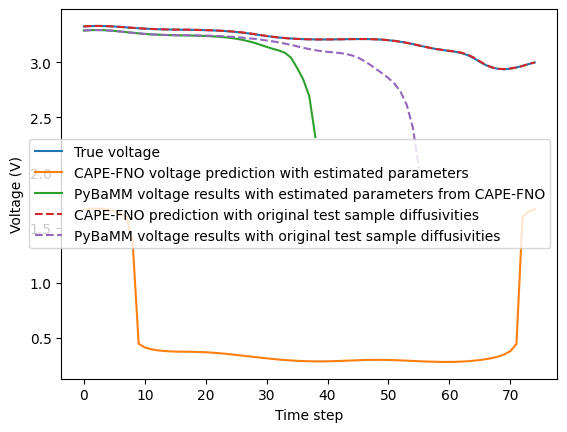

In [ ]:
plt.plot(V_data, label="True voltage")
plt.plot(V_best, label="CAPE-FNO voltage prediction with estimated parameters")
plt.plot(V_best_pybamm, label="PyBaMM voltage results with estimated parameters from CAPE-FNO")
plt.plot(V_test_pred, label="CAPE-FNO prediction with original test sample diffusivities", linestyle='--')
plt.plot(V_true_pybamm, label="PyBaMM voltage results with original test sample diffusivities", linestyle='--')
plt.xlabel("Time step")
plt.ylabel("Voltage (V)")
plt.legend()
plt.show()

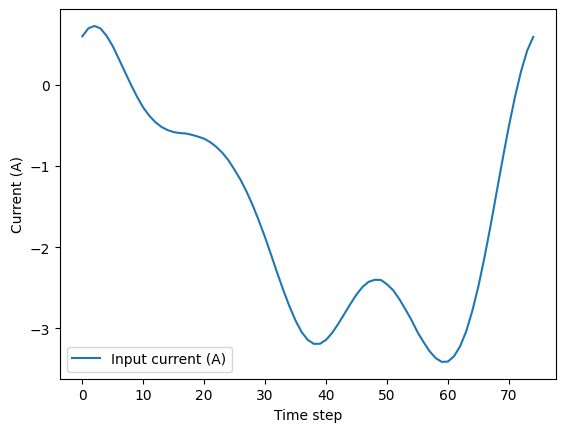

In [ ]:
plt.plot(func_I[test_idx], label="Input current (A)")
plt.xlabel("Time step")
plt.ylabel("Current (A)")
plt.legend()
plt.show()

In [ ]:
V_best = res.fun

In [ ]:
V_best

2.707082509994507

In [ ]:
import pybamm
import numpy as np

# ▶  a baseline Li-ion model  (SPMe is fast; swap for DFN if you prefer)
pybamm_model = pybamm.lithium_ion.SPM()

# ▶  time grid that matches your measured voltage trace V_true
t_eval = np.linspace(0, 3600, 75)   # dt = sample spacing [s]

# ▶  current profile: use your measured current array `func_I`
#     (shape (T,)).  Convert to an interpolant so PyBaMM can call it at any t.
current_fun = pybamm.Interpolant(t_eval, -func_I[test_idx].squeeze(), pybamm.t)

#     Tell the model to use that function instead of the built-in C-rate
params_bat["Current function [A]"] = current_fun

D_anode_candidate = 10 ** best_log10_Dan
D_cathode_candidate = 10 ** best_log10_Dca

params_bat["Negative particle diffusivity [m2.s-1]"] = D_anode_candidate
params_bat["Positive particle diffusivity [m2.s-1]"] = D_cathode_candidate

soc = test_data["soc"][test_idx]

sim = pybamm.Simulation(model=pybamm_model, parameter_values=params_bat)
sim.solve(initial_soc = soc[0], t_eval=t_eval)

V_best_pybamm = sim.solution["Terminal voltage [V]"](t_eval)

In [ ]:
# ---- design space ----------------------------------------
dimensions_pybamm = [
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dan_pybamm"),
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dca_pybamm"),
]

In [ ]:
@use_named_args(dimensions_pybamm)
def obj_voltage_pybamm(log10_Dan_pybamm, log10_Dca_pybamm):

    try:
        # --- 1.  normalise the candidate diffusivities ------------
        D_anode_candidate = 10 ** log10_Dan_pybamm
        D_cathode_candidate = 10 ** log10_Dca_pybamm

        params_bat["Negative particle diffusivity [m2.s-1]"] = D_anode_candidate
        params_bat["Positive particle diffusivity [m2.s-1]"] = D_cathode_candidate

        sim = pybamm.Simulation(pybamm_model, parameter_values=params_bat)
        sim.solve(initial_soc = soc[0], t_eval=t_eval)

        V_pred = sim.solution["Terminal voltage [V]"](t_eval)
        # --- 3.  voltage RMSE (you can use MAE or any other scalar) -------------
        rmse = jnp.sqrt(jnp.mean((V_pred - V_data) ** 2))
        if np.isnan(rmse):
            return 1e8
        return float(rmse)

    except Exception as e:
        return float('1e8')


In [ ]:
res_pybamm = gp_minimize(
    obj_voltage_pybamm,
    dimensions=dimensions_pybamm,
    n_calls=60,            # ±25–35 evaluations per dimension is usually plenty
    n_initial_points=12,   # random Sobol/Bach search first
    acq_func="EI",         # expected improvement
    random_state=0,
)

best_log10_Dan_pybamm, best_log10_Dca_pybamm = res_pybamm.x
print(f"Best log10(Dan) = {best_log10_Dan_pybamm:.3f}")
print(f"Best log10(Dca) = {best_log10_Dca_pybamm:.3f}")
print(f"Voltage-curve RMSE = {res_pybamm.fun:.4e}")

Best log10(Dan) = -13.221
Best log10(Dca) = -12.467
Voltage-curve RMSE = 1.0000e+08
